# 📦 Damaged vs Good Packages — Image Classifier
Train a binary image classifier using TensorFlow + transfer learning (MobileNetV2).

## 1. Install & Import Dependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Download Dataset from Roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="WBhh6jyHHZZ6iU1N2atG")
project = rf.workspace("aadhavs-first-workspace").project("damaged-vs-good-packages")
version = project.version(1)
dataset = version.download("folder")

DATASET_DIR = dataset.location
print('Dataset location:', DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...
Dataset location: /Users/vaughnaquino/acads/cs180/RipEye/notebooks/Damaged-vs-good-packages-1


## 3. Explore the Dataset

In [3]:
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATASET_DIR, split)
    if not os.path.exists(split_path):
        continue
    print(f'\n--- {split.upper()} ---')
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f'  {cls}: {count} images')


--- TRAIN ---
  damaged: 183 images
  intact: 229 images

--- VALID ---
  damaged: 51 images
  intact: 61 images

--- TEST ---
  damaged: 22 images
  intact: 35 images


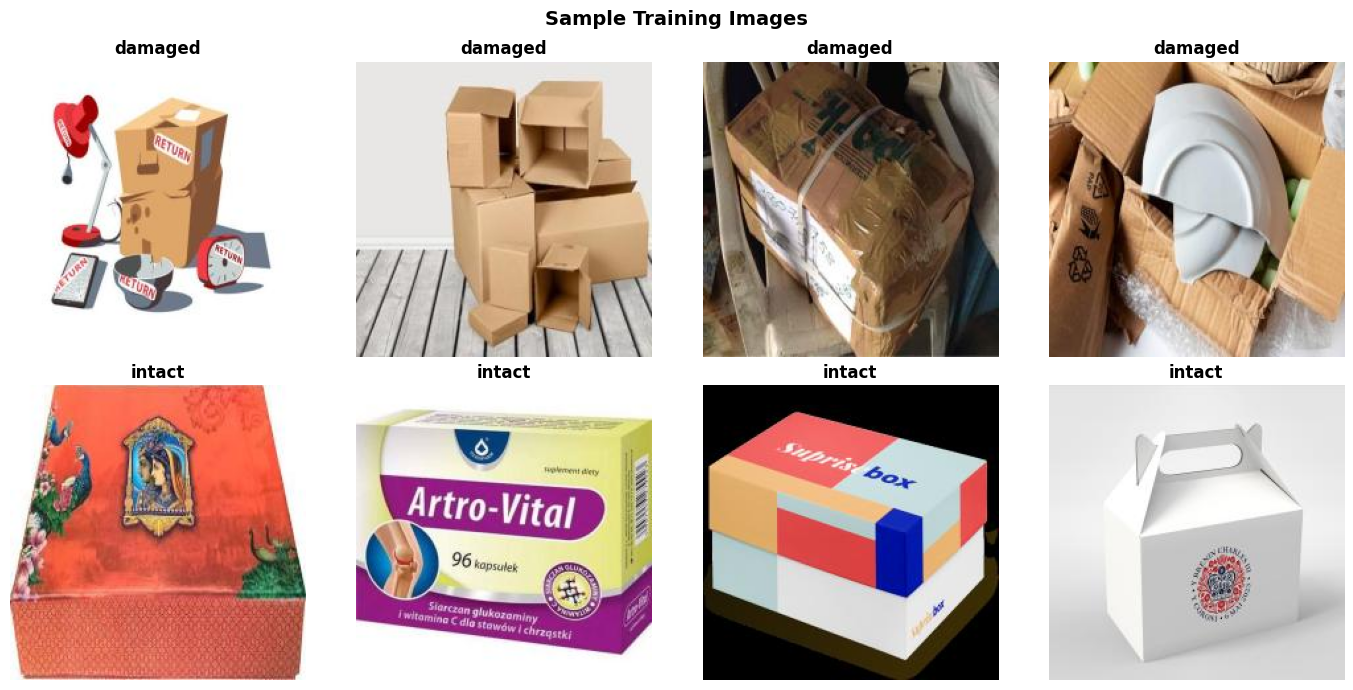

In [4]:
# Preview some training images
train_path = os.path.join(DATASET_DIR, 'train')
classes = sorted(os.listdir(train_path))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for row, cls in enumerate(classes[:2]):
    cls_path = os.path.join(train_path, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for col, fname in enumerate(imgs[:4]):
        img = plt.imread(os.path.join(cls_path, fname))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Configuration

In [5]:
# ── Tweak these to your liking ──────────────────────────────
IMG_SIZE    = (224, 224)   # MobileNetV2 native size
BATCH_SIZE  = 32
EPOCHS_HEAD = 10           # train only the new head first
EPOCHS_FINE = 10           # fine-tune top layers of base model
LEARNING_RATE = 1e-3
FINE_TUNE_LR  = 1e-5
FINE_TUNE_AT  = 100        # unfreeze layers from this index onward
# ────────────────────────────────────────────────────────────

NUM_CLASSES = len(classes)
print('Classes:', classes)
print('Num classes:', NUM_CLASSES)

Classes: ['damaged', 'intact']
Num classes: 2


## 5. Build tf.data Pipelines

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(split, shuffle=False):
    path = os.path.join(DATASET_DIR, split)
    ds = keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        label_mode='categorical' if NUM_CLASSES > 2 else 'binary',
        class_names=classes,
    )
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset('train', shuffle=True)
val_ds   = make_dataset('valid')
test_ds  = make_dataset('test')

print('Train batches:', len(train_ds))
print('Val   batches:', len(val_ds))
print('Test  batches:', len(test_ds))

Found 412 files belonging to 2 classes.
Found 112 files belonging to 2 classes.
Found 57 files belonging to 2 classes.
Train batches: 13
Val   batches: 4
Test  batches: 2


## 6. Data Augmentation

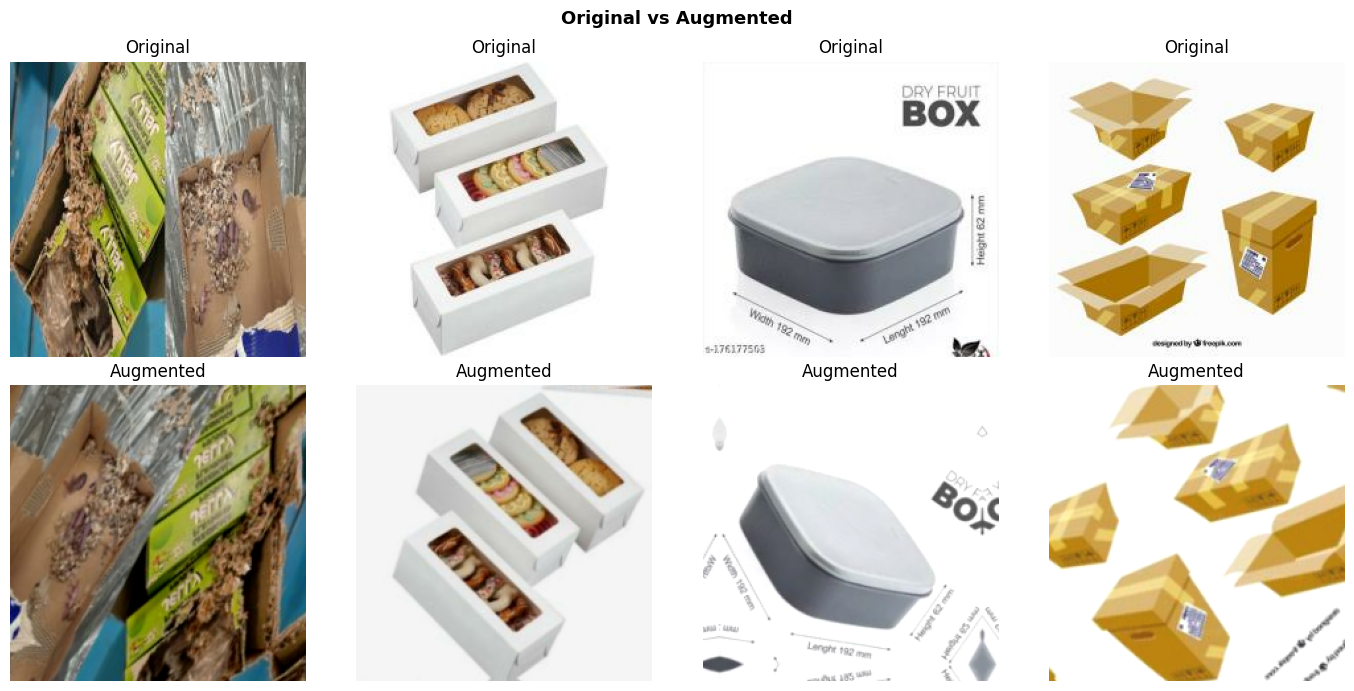

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# Preview augmented images
sample_images, _ = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Original vs Augmented', fontsize=13, fontweight='bold')
for i in range(4):
    axes[0, i].imshow(sample_images[i].numpy().astype('uint8'))
    axes[0, i].set_title('Original'); axes[0, i].axis('off')
    aug = data_augmentation(tf.expand_dims(sample_images[i], 0))[0]
    axes[1, i].imshow(aug.numpy().astype('uint8'))
    axes[1, i].set_title('Augmented'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

## 7. Build the Model (MobileNetV2 Transfer Learning)

In [8]:
def build_model():
    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    # Augment only during training
    x = data_augmentation(inputs)

    # MobileNetV2 expects inputs in [-1, 1]
    x = layers.Rescaling(1./127.5, offset=-1)(x)

    # Pretrained base — frozen initially
    base_model = keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Output head
    if NUM_CLASSES == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'
        metrics = ['accuracy', keras.metrics.AUC(name='auc')]
    else:
        outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
        loss = 'categorical_crossentropy'
        metrics = ['accuracy']

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss=loss,
        metrics=metrics,
    )
    return model, base_model

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Phase 1 — Train the Head

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5073 - auc: 0.4897 - loss: 0.8008
Epoch 1: val_loss improved from None to 0.53713, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 284ms/step - accuracy: 0.5534 - auc: 0.5468 - loss: 0.7530 - val_accuracy: 0.7411 - val_auc: 0.8295 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7232 - auc: 0.7645 - loss: 0.5786
Epoch 2: val_loss improved from 0.53713 to 0.43556, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.7063 - auc: 0.7659 - loss: 0.5805 - val_accuracy: 0.8482 - val_auc: 0.9086 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7199 - auc: 0.8005 - loss: 0.5390
Epoch 3: val_loss improved from 0.43556 to 0.39032, saving model to best_model.kera

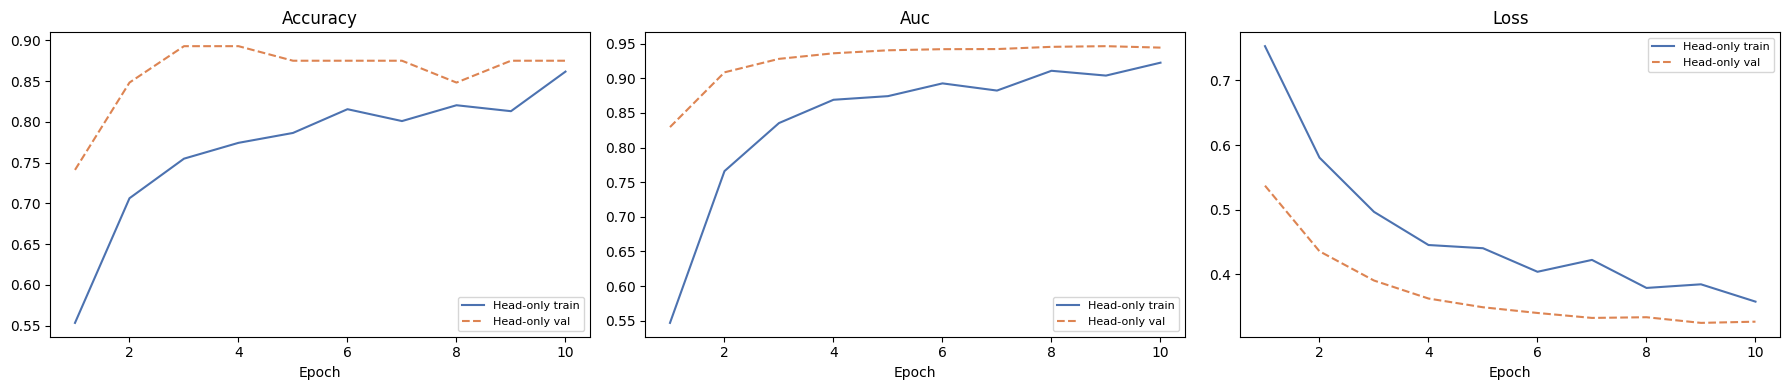

In [19]:
def plot_history(histories, titles):
    metrics = [k for k in histories[0].history 
               if not k.startswith('val_') and f'val_{k}' in histories[0].history]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1: axes = [axes]
    colors = [('#4C72B0','#DD8452'), ('#55A868','#C44E52')]
    offset = 0
    for h, title in zip(histories, titles):
        epochs = range(offset + 1, offset + len(h.epoch) + 1)
        for ax, metric in zip(axes, metrics):
            c_train, c_val = colors[histories.index(h)]
            ax.plot(epochs, h.history[metric], color=c_train, label=f'{title} train')
            ax.plot(epochs, h.history[f'val_{metric}'], color=c_val, linestyle='--', label=f'{title} val')
            ax.set_title(metric.capitalize()); ax.legend(fontsize=8)
        offset += len(h.epoch)
    for ax in axes: ax.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()


# plot_history(history1)
plot_history([history1], ['Head-only'])

## 9. Phase 2 — Fine-Tune Top Layers

In [12]:
# Unfreeze top layers of the base model
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning top {trainable} layers of base model')

# Recompile with a much lower learning rate
loss = 'binary_crossentropy' if NUM_CLASSES == 2 else 'categorical_crossentropy'
metrics_list = ['accuracy', keras.metrics.AUC(name='auc')] if NUM_CLASSES == 2 else ['accuracy']
model.compile(
    optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
    loss=loss,
    metrics=metrics_list,
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks,
)

Fine-tuning top 54 layers of base model
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.6722 - auc: 0.8609 - loss: 0.6693
Epoch 1: val_loss improved from 0.32477 to 0.31761, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 430ms/step - accuracy: 0.6893 - auc: 0.8622 - loss: 0.6313 - val_accuracy: 0.8929 - val_auc: 0.9491 - val_loss: 0.3176 - learning_rate: 1.0000e-05
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6567 - auc: 0.8310 - loss: 0.6863
Epoch 2: val_loss improved from 0.31761 to 0.31130, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 367ms/step - accuracy: 0.6917 - auc: 0.8495 - loss: 0.6222 - val_accuracy: 0.8839 - val_auc: 0.9478 - val_loss: 0.3113 - learning_rate: 1.0000e-05
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6758 - auc: 0.8450 - loss: 0.6332
Epoch 3: val_loss improved from

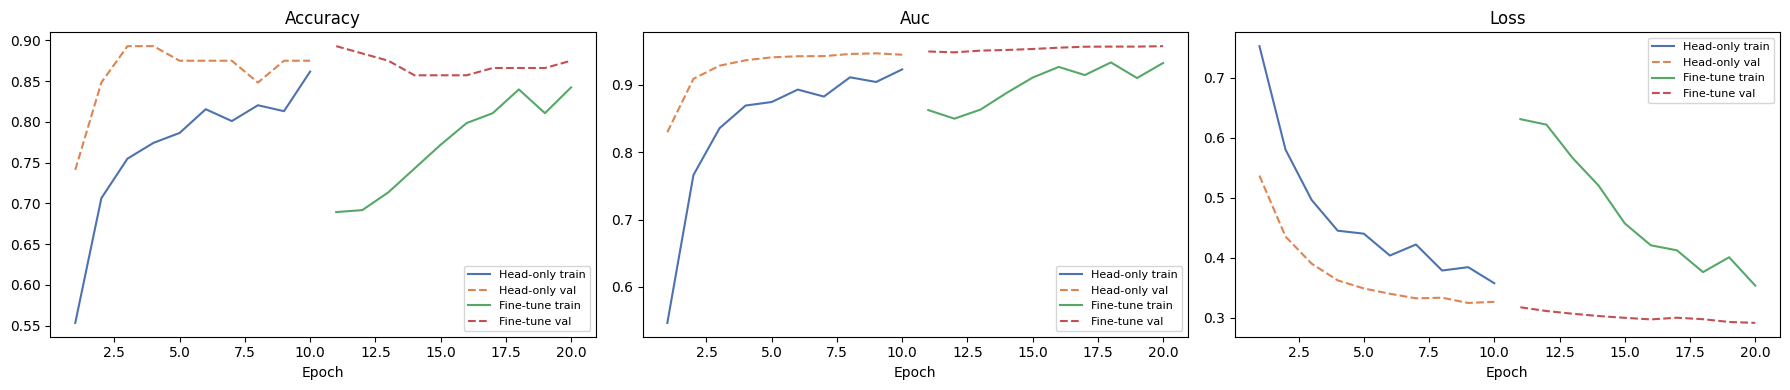

In [20]:
plot_history([history1, history2], ['Head-only', 'Fine-tune'])
# plot_history(history2)

## 10. Evaluate on Test Set

In [14]:
# Load the best saved checkpoint
best_model = keras.models.load_model('best_model.keras')

results = best_model.evaluate(test_ds, verbose=1)
for name, val in zip(best_model.metrics_names, results):
    print(f'{name}: {val:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.8596 - auc: 0.9461 - loss: 0.3287
loss: 0.3287
compile_metrics: 0.8596



Classification Report:
              precision    recall  f1-score   support

     damaged       0.75      0.95      0.84        22
      intact       0.97      0.80      0.88        35

    accuracy                           0.86        57
   macro avg       0.86      0.88      0.86        57
weighted avg       0.88      0.86      0.86        57



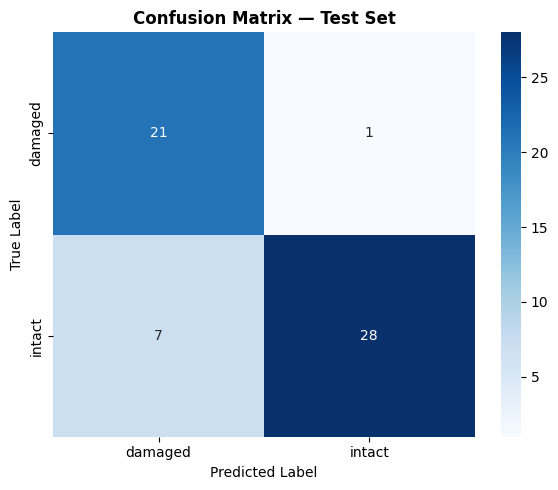

In [15]:
# Collect all predictions
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    if NUM_CLASSES == 2:
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_true.extend(labels.numpy().astype(int).flatten())
    else:
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 11. Visualize Predictions

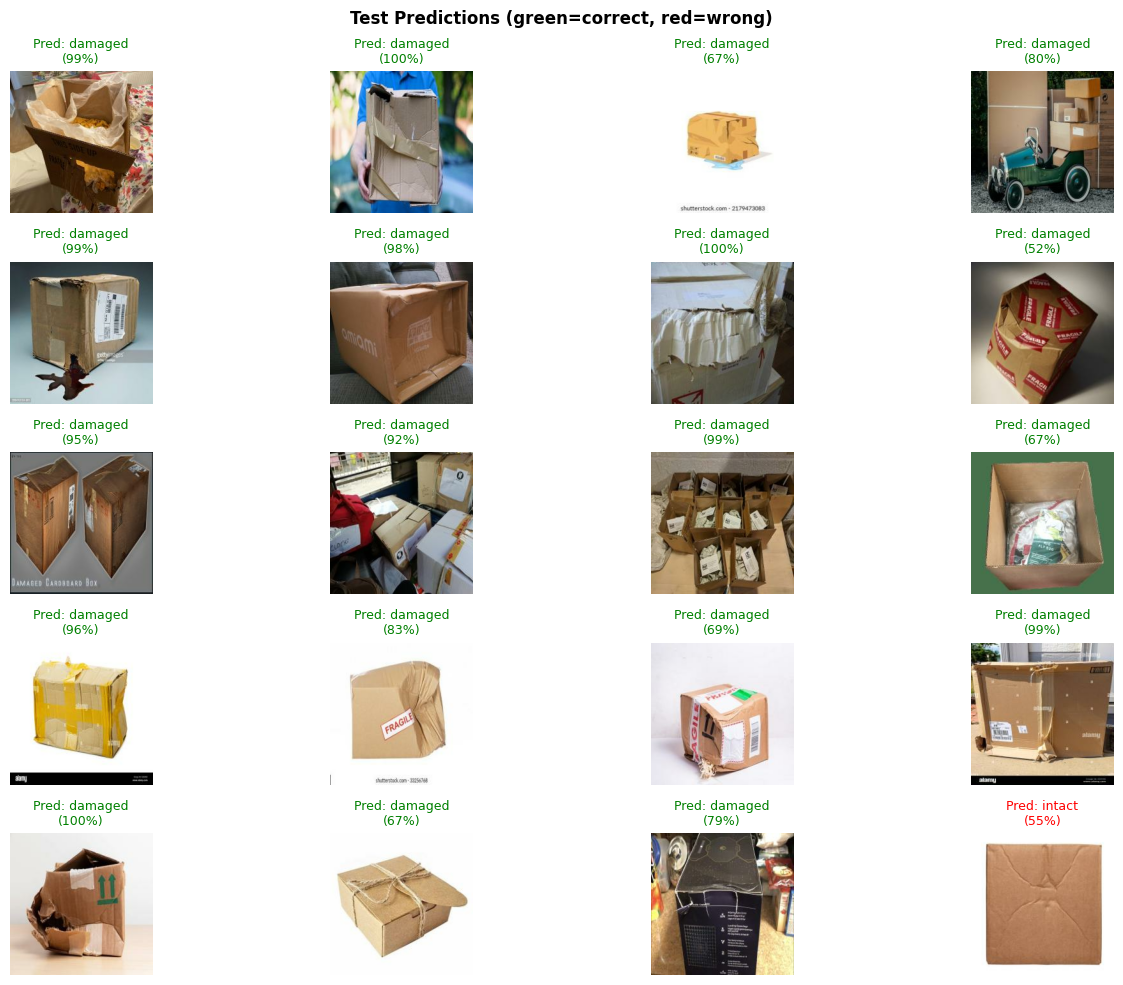

In [28]:
images_batch, labels_batch = next(iter(test_ds))
preds_batch = best_model.predict(images_batch, verbose=0)

n = min(20, len(images_batch))
fig, axes = plt.subplots(5, 4, figsize=(14, 10))
fig.suptitle('Test Predictions (green=correct, red=wrong)', fontweight='bold')

for i, ax in enumerate(axes.flat[:n]):
    img = images_batch[i].numpy().astype('uint8')
    if NUM_CLASSES == 2:
        pred_idx = int(preds_batch[i][0] > 0.5)
        true_idx = int(labels_batch[i][0].numpy())
        conf = float(preds_batch[i][0]) if pred_idx == 1 else 1 - float(preds_batch[i][0])
    else:
        pred_idx = int(np.argmax(preds_batch[i]))
        true_idx = int(np.argmax(labels_batch[i].numpy()))
        conf = float(np.max(preds_batch[i]))

    color = 'green' if pred_idx == true_idx else 'red'
    ax.imshow(img)
    ax.set_title(f'Pred: {classes[pred_idx]}\n({conf:.0%})', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout(); plt.show()

## 12. Save & Export

In [31]:
# Save in native Keras format
best_model.save('damaged_vs_good_classifier.keras')
print('Model saved to: damaged_vs_good_classifier.keras')


Model saved to: damaged_vs_good_classifier.keras


## 13. Run Inference on a Single Image

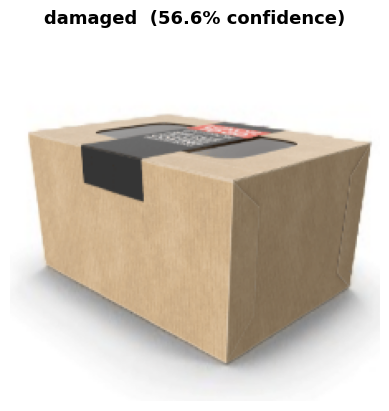

('damaged', 0.5662932693958282)

In [34]:
def predict_image(image_path, model=best_model):
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, 0)  # (1, H, W, 3)
    pred = model.predict(arr, verbose=0)

    if NUM_CLASSES == 2:
        prob = float(pred[0][0])
        idx = int(prob > 0.5)
        conf = float(prob) if idx == 1 else 1 - float(prob)
    else:
        idx = int(np.argmax(pred[0]))
        conf = float(np.max(pred[0]))

    plt.imshow(img); plt.axis('off')
    plt.title(f'{classes[idx]}  ({conf:.1%} confidence)', fontsize=13, fontweight='bold')
    plt.show()
    return classes[idx], conf

# Example usage:
predict_image('test/01.png')